# The Price is Right

Today we build a more complex solution for estimating prices of goods.

1. Day 2.0 notebook: create a RAG database with our 400,000 training data
2. Day 2.1 notebook: visualize in 2D
3. Day 2.2 notebook: visualize in 3D
4. Day 2.3 notebook: build and test a RAG pipeline with GPT-4o-mini
5. Day 2.4 notebook: (a) bring back our Random Forest pricer (b) Create a Ensemble pricer that allows contributions from all the pricers

Phew! That's a lot to get through in one day!

## PLEASE NOTE:

We already have a very powerful product estimator with our proprietary, fine-tuned LLM. Most people would be very satisfied with that! The main reason we're adding these extra steps is to deepen your expertise with RAG and with Agentic workflows.

## We will go fast today! Hold on to your hat..

In [1]:
# imports

import os
import re
from dotenv import load_dotenv
import pickle
from openai import OpenAI
from sentence_transformers import SentenceTransformer
import chromadb

import sys
sys.path.append('../week6') 
from testing import Tester

In [2]:
# environment

load_dotenv(override=True)
os.environ['OPENAI_API_KEY'] = os.getenv('OPENAI_API_KEY', 'your-key-if-not-using-env')
os.environ['HF_TOKEN'] = os.getenv('HF_TOKEN', 'your-key-if-not-using-env')

In [3]:
openai = OpenAI()

In [4]:
# Load in the test pickle file
# See the section "Back to the PKL files" in the day2.0 notebook
# for instructions on obtaining this test.pkl file

with open('../week6/test_lite.pkl', 'rb') as file:
    test = pickle.load(file)

In [5]:
print(f"Test length: {len(test)}")

Test length: 3000


In [6]:
def make_context(similars, prices):
    message = "To provide some context, here are some other items that might be similar to the item you need to estimate.\n\n"
    for similar, price in zip(similars, prices):
        message += f"Potentially related product:\n{similar}\nPrice is ${price:.2f}\n\n"
    return message

In [7]:
def messages_for(item, similars, prices):
    system_message = "You estimate prices of items. Reply only with the price, no explanation"
    user_prompt = make_context(similars, prices)
    user_prompt += "And now the question for you:\n\n"
    user_prompt += item.test_prompt().replace(" to the nearest dollar","").replace("\n\nPrice is $","")
    return [
        {"role": "system", "content": system_message},
        {"role": "user", "content": user_prompt},
        {"role": "assistant", "content": "Price is $"}
    ]

In [8]:
DB = "products_vectorstore"

In [9]:
client = chromadb.PersistentClient(path=DB)
collection = client.get_or_create_collection('products')

In [10]:
print(f"📊 向量庫中紀錄數量：{collection.count()} 筆")

📊 向量庫中紀錄數量：100000 筆


In [11]:
def description(item):
    text = item.prompt.replace("How much does this cost to the nearest dollar?\n\n", "")
    return text.split("\n\nPrice is $")[0]

In [12]:
description(test[0])

"M626 Durun\nAttention! Due to the size of the tires, Packages might be SEPARATED in the courier facility and not be DELIVERED on the SAME DAY, even though we do ship them together. All tracking information can be checked on courier's website.Durun Durun M626 is a performance and high performance, all season tire manufactured for passenger vehicles and SUVs. The tread design and all season compound increase the dry, wet and winter weather traction. The wide grooves actively resist hydroplaning by dispersing water and slush. The constant road contact boosts the steering responsiveness and driving stability greatly. The shoulder tread blocks enhance the cornering ability and power. The M626 has great high speed performing ability as it does not deform under the high speed driving pressure.FeaturesAll"

In [13]:
model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

In [14]:
def vector(item):
    return model.encode([description(item)])

## Find 5 similar results by using collection.query
- n_results=5

In [15]:
def find_similars(item):
    results = collection.query(query_embeddings=vector(item).astype(float).tolist(), n_results=5) # Return 5 similars 
    documents = results['documents'][0][:]
    prices = [m['price'] for m in results['metadatas'][0][:]]
    return documents, prices

In [16]:
print(test[1].prompt)

How much does this cost to the nearest dollar?

FEITIAN MultiPass K32 USB Security Key - Two Factor Authenticator with Multiple Interfaces - USB-C, NFC, Bluetooth - FIDO2 + FIDO U2F - Help Prevent Account Takeovers with Multi-Factor Authentication
Multiple-Interface FIDO U2F certified security key USB interface works without any drivers in Windows, Linux, Mac OS with Chrome, Firefox, etc. NFC and Bluetooth interface works for NFC compatible devices, mobile phones, and NFC also works with contactless readers Small, portable, and fits on a keychain Helps protect your accounts from phishing and other cyber-attacks Dimensions 1.5 x 1.5 x 0.3 inches, Weight 0.845 ounces, model number K32, Batteries 1 Lithium Ion batteries required. (

Price is $35.00


In [17]:
documents, prices = find_similars(test[1])

In [18]:
# Due to n_results=5
print(f"Documents length: {len(documents)}")
print(f"Prices length: {len(prices)}")

Documents length: 5
Prices length: 5


In [19]:
print(make_context(documents, prices))

To provide some context, here are some other items that might be similar to the item you need to estimate.

Potentially related product:
Q-ZIORE CAC Reader Military, Smart CAC Card Reader DOD Military, USB Common Access CAC, Compatible with Windows, Mac OS
Spefications New generation DOD Military CAC reader USB smart card reader in accordance with standard. USB2.0 full transmission speed. Cable length 1.5M. Material High quality ABS material anti overheating and wear. Input power DC5V, receive the power supply from the USB terminal of the computer when use. Easy to Operate No need driver, just Plug and Play. Simply connect the USB terminal to automatically identify. It can be used for all contact-type smart cards, such as online banking or digital signature applications AKO, OWA, DKO, JKO, NKO, ActivClient, BOL,
Price is $11.99

Potentially related product:
Portable Micro USB Leather Keychain, USB Charge Data Sync Cable for Android, Samsung, HTC, Nexus, Nokia, LG, Sony and More
Color B

In [20]:
print(messages_for(test[1], documents, prices))

[{'role': 'system', 'content': 'You estimate prices of items. Reply only with the price, no explanation'}, {'role': 'user', 'content': "To provide some context, here are some other items that might be similar to the item you need to estimate.\n\nPotentially related product:\nQ-ZIORE CAC Reader Military, Smart CAC Card Reader DOD Military, USB Common Access CAC, Compatible with Windows, Mac OS\nSpefications New generation DOD Military CAC reader USB smart card reader in accordance with standard. USB2.0 full transmission speed. Cable length 1.5M. Material High quality ABS material anti overheating and wear. Input power DC5V, receive the power supply from the USB terminal of the computer when use. Easy to Operate No need driver, just Plug and Play. Simply connect the USB terminal to automatically identify. It can be used for all contact-type smart cards, such as online banking or digital signature applications AKO, OWA, DKO, JKO, NKO, ActivClient, BOL,\nPrice is $11.99\n\nPotentially rela

In [21]:
def get_price(s):
    s = s.replace('$','').replace(',','')
    match = re.search(r"[-+]?\d*\.\d+|\d+", s)
    return float(match.group()) if match else 0

In [22]:
get_price("The price for this is $99.99")

99.99

In [23]:
# The function for gpt-4o-mini

def gpt_4o_mini_rag(item):
    documents, prices = find_similars(item)
    response = openai.chat.completions.create(
        model="gpt-4o-mini", 
        messages=messages_for(item, documents, prices),
        seed=42,
        max_tokens=5
    )
    reply = response.choices[0].message.content
    return get_price(reply)

In [24]:
gpt_4o_mini_rag(test[1])

39.99

In [25]:
test[1].price

35.4

Process status: 10% | Hits Rate so far: 84.0%
Process status: 20% | Hits Rate so far: 84.0%
Process status: 30% | Hits Rate so far: 84.0%
Process status: 40% | Hits Rate so far: 84.0%
Process status: 50% | Hits Rate so far: 85.6%
Process status: 60% | Hits Rate so far: 86.7%
Process status: 70% | Hits Rate so far: 87.4%
Process status: 80% | Hits Rate so far: 88.0%
Process status: 90% | Hits Rate so far: 87.6%
Process status: 100% | Hits Rate so far: 88.0%


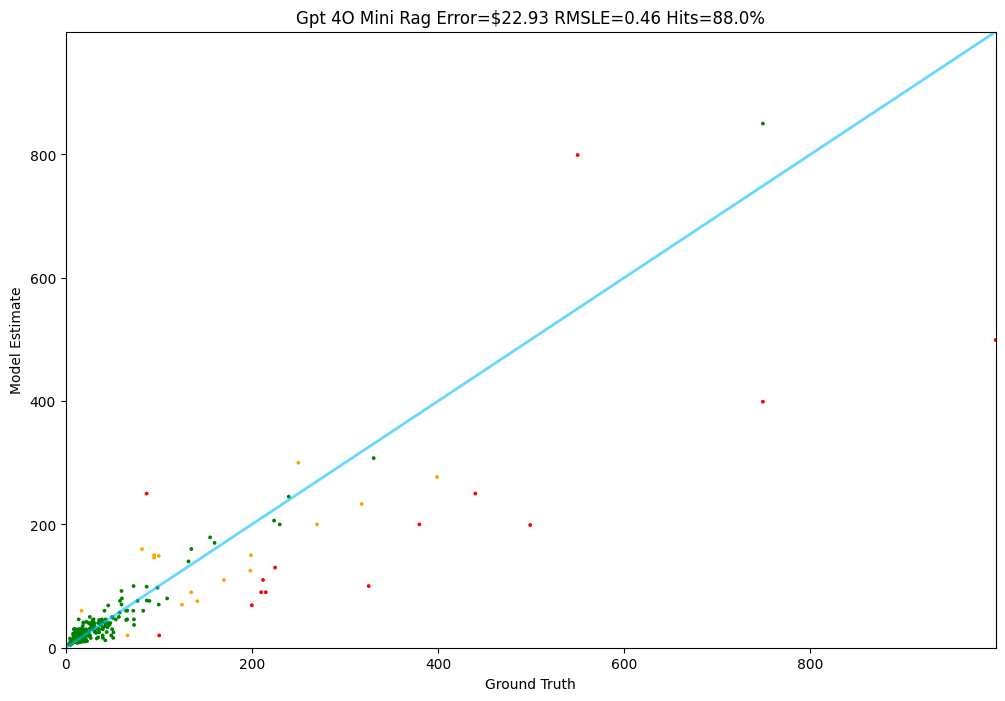

In [26]:
Tester.test(gpt_4o_mini_rag, test)

## Optional Extra: Trying a DeepSeek API call instead of OpenAI

If you have a DeepSeek API key, we will use it here as an alternative implementation; otherwise skip to the next section..

In [27]:
# Connect to DeepSeek using the OpenAI client python library

deepseek_api_key = os.getenv("DEEPSEEK_API_KEY")
deepseek_via_openai_client = OpenAI(api_key=deepseek_api_key,base_url="https://api.deepseek.com")

In [28]:
# Added some retry logic here because DeepSeek is very oversubscribed and sometimes fails..

def deepseek_api_rag(item):
    documents, prices = find_similars(item)
    retries = 8
    done = False
    while not done and retries > 0:
        try:
            response = deepseek_via_openai_client.chat.completions.create(
                model="deepseek-chat", 
                messages=messages_for(item, documents, prices),
                seed=42,
                max_tokens=8
            )
            reply = response.choices[0].message.content
            done = True
        except Exception as e:
            print(f"Error: {e}")
            retries -= 1
    return get_price(reply)

In [29]:
deepseek_api_rag(test[1])

0

Process status: 10% | Hits Rate so far: 84.0%
Process status: 20% | Hits Rate so far: 82.0%
Process status: 30% | Hits Rate so far: 80.0%
Process status: 40% | Hits Rate so far: 79.0%
Process status: 50% | Hits Rate so far: 80.0%
Process status: 60% | Hits Rate so far: 81.3%
Process status: 70% | Hits Rate so far: 82.9%
Process status: 80% | Hits Rate so far: 83.0%
Process status: 90% | Hits Rate so far: 82.7%
Process status: 100% | Hits Rate so far: 83.2%


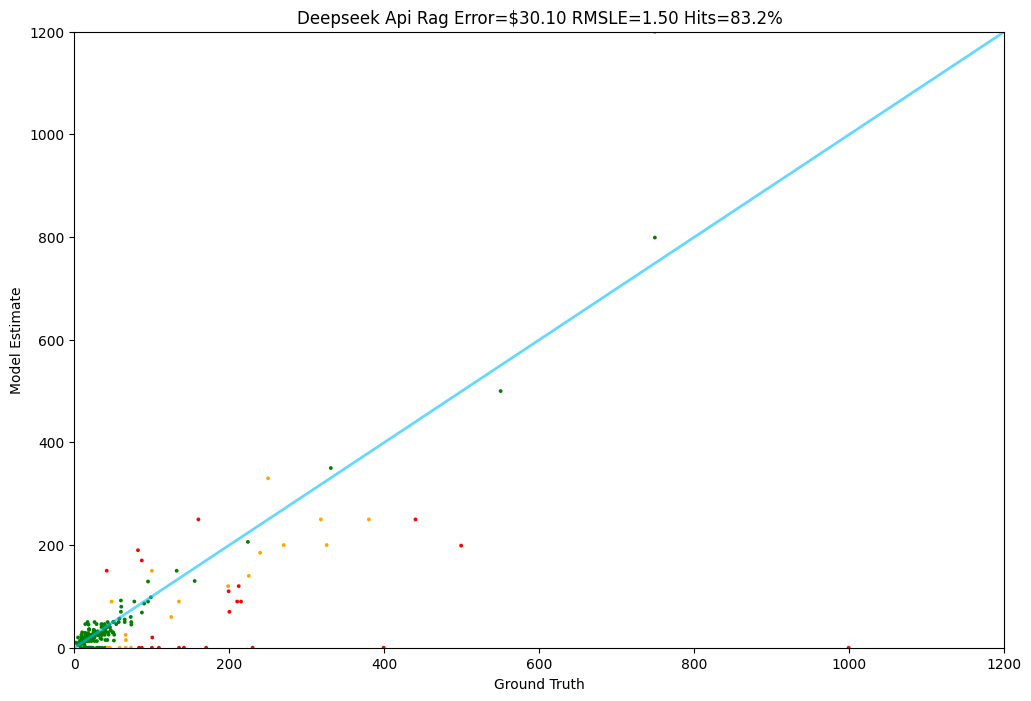

In [30]:
Tester.test(deepseek_api_rag, test)

## And now to wrap this in an "Agent" class

In [31]:
from agents.frontier_agent import FrontierAgent

In [32]:
# Let's print the logs so we can see what's going on

import logging
root = logging.getLogger()
root.setLevel(logging.INFO)

In [33]:
agent = FrontierAgent(collection)

INFO:root:[Frontier Agent] Initializing Frontier Agent
INFO:root:[Frontier Agent] Frontier Agent is set up with DeepSeek
INFO:sentence_transformers.SentenceTransformer:Use pytorch device_name: cpu
INFO:sentence_transformers.SentenceTransformer:Load pretrained SentenceTransformer: sentence-transformers/all-MiniLM-L6-v2
INFO:root:[Frontier Agent] Frontier Agent is ready


In [34]:
agent.price("Quadcast HyperX condenser mic for high quality podcasting")

INFO:root:[Frontier Agent] Frontier Agent is performing a RAG search of the Chroma datastore to find 5 similar products


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

INFO:root:[Frontier Agent] Frontier Agent has found similar products
INFO:root:[Frontier Agent] Frontier Agent is about to call deepseek-chat with context including 5 similar products
INFO:httpx:HTTP Request: POST https://api.deepseek.com/chat/completions "HTTP/1.1 200 OK"
INFO:root:[Frontier Agent] Frontier Agent completed - predicting $149.99


149.99

In [35]:
from agents.specialist_agent import SpecialistAgent

In [36]:
agent2 = SpecialistAgent()

INFO:root:[Specialist Agent] Specialist Agent is initializing - connecting to modal
INFO:root:[Specialist Agent] Specialist Agent is ready


In [37]:
agent2.price("Quadcast HyperX condenser mic for high quality podcasting")

INFO:root:[Specialist Agent] Specialist Agent is calling remote fine-tuned model
INFO:root:[Specialist Agent] Specialist Agent completed - predicting $60.00


60.0